In [1]:
# Standardized SMOTE pipeline (ResNet50)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical

2026-04-24 18:15:32.024765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777054532.226091      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777054532.290009      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777054532.771761      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777054532.771802      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777054532.771805      55 computation_placer.cc:177] computation placer alr

In [2]:
SEED = 42
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 30
BASE_DIR = '/kaggle/input/datasets/insyirahazman/menstrual-blood-color/data_256_256'

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
rows = []
for label in sorted(os.listdir(BASE_DIR)):
    class_dir = os.path.join(BASE_DIR, label)
    if not os.path.isdir(class_dir):
        continue
    for fname in sorted(os.listdir(class_dir)):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
            rows.append({'filepath': os.path.join(class_dir, fname), 'label': label})
df = pd.DataFrame(rows)
print(df.head())

                                            filepath  label
0  /kaggle/input/datasets/insyirahazman/menstrual...  Black
1  /kaggle/input/datasets/insyirahazman/menstrual...  Black
2  /kaggle/input/datasets/insyirahazman/menstrual...  Black
3  /kaggle/input/datasets/insyirahazman/menstrual...  Black
4  /kaggle/input/datasets/insyirahazman/menstrual...  Black


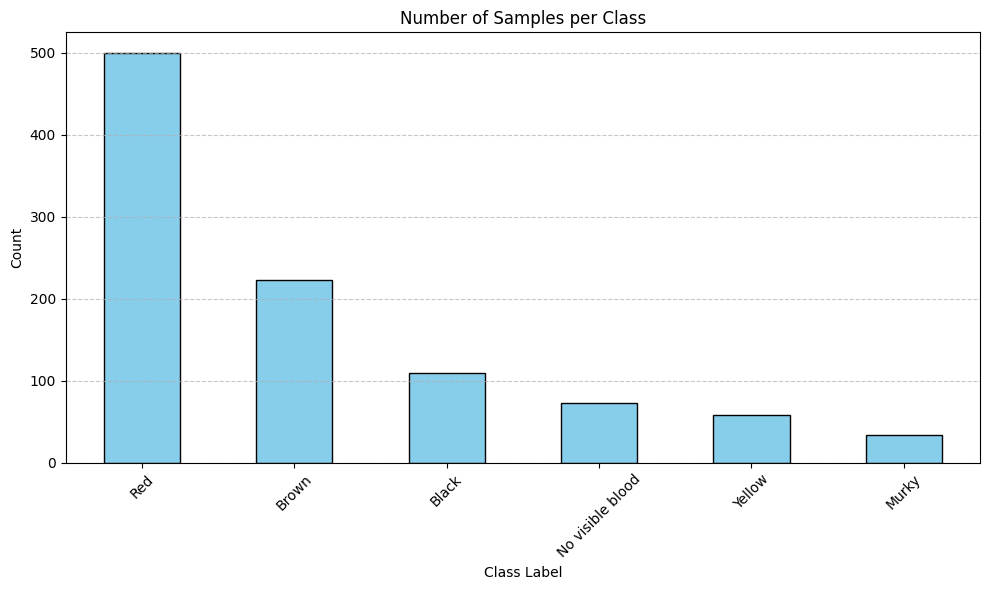

In [4]:
class_counts = df['label'].value_counts()
plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Samples per Class')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [5]:
images = []
labels = []
for i, row in df.iterrows():
    try:
        img = load_img(row['filepath'], target_size=IMG_SIZE)
        img_array = img_to_array(img).astype(np.float32) / 255.0
        images.append(img_array)
        labels.append(row['label'])
        if (i + 1) % 100 == 0:
            print(f'Loaded {i + 1} images.')
    except Exception as e:
        print(f"Error loading {row['filepath']}: {e}")

images = np.array(images, dtype=np.float32)
labels = np.array(labels)

le = LabelEncoder()
labels_int = le.fit_transform(labels)
num_classes = len(le.classes_)

Loaded 100 images.
Loaded 200 images.
Loaded 300 images.
Loaded 400 images.
Loaded 500 images.
Loaded 600 images.
Loaded 700 images.
Loaded 800 images.
Loaded 900 images.


In [6]:
X_temp, X_test, y_temp, y_test_int = train_test_split(
    images, labels_int, test_size=0.2, random_state=SEED, stratify=labels_int
)
X_train_raw, X_val, y_train_raw, y_val_int = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

X_train_flat = X_train_raw.reshape((X_train_raw.shape[0], -1))
X_train_smote_flat, y_train_int = SMOTE(random_state=SEED).fit_resample(X_train_flat, y_train_raw)
X_train = X_train_smote_flat.reshape((-1, IMG_SIZE[0], IMG_SIZE[1], 3)).astype(np.float32)

y_train = to_categorical(y_train_int, num_classes=num_classes)
y_val = to_categorical(y_val_int, num_classes=num_classes)
y_test = to_categorical(y_test_int, num_classes=num_classes)

print('Train set (after SMOTE):', X_train.shape, y_train.shape)
print('Validation set:', X_val.shape, y_val.shape)
print('Test set:', X_test.shape, y_test.shape)

Train set (after SMOTE): (1800, 256, 256, 3) (1800, 6)
Validation set: (200, 256, 256, 3) (200, 6)
Test set: (200, 256, 256, 3) (200, 6)


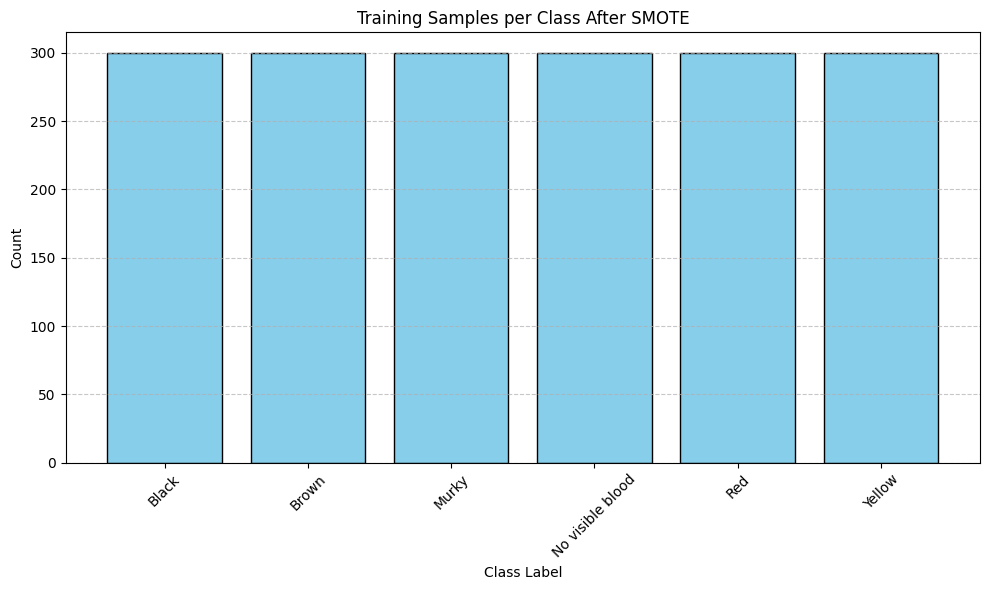

In [7]:
smote_counts = np.bincount(y_train_int, minlength=num_classes)
plt.figure(figsize=(10, 6))
plt.bar(le.classes_, smote_counts, color='skyblue', edgecolor='black')
plt.title('Training Samples per Class After SMOTE')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
base_model.trainable = True
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

I0000 00:00:1777054575.265766      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777054575.272375      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,777,862 (94.52 MB)

 Trainable params: 24,720,646 (94.30 MB)

 Non-trainable params: 57,216 (223.50 KB)

In [9]:
model_path = '/kaggle/working/resnet50_smote.h5'
callbacks = [
    ModelCheckpoint(model_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-8, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

best_model = tf.keras.models.load_model(model_path)

Epoch 1/30


I0000 00:00:1777054612.312052     129 service.cc:152] XLA service 0x7f4338006a50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777054612.312109     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777054612.312117     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777054618.241028     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-24 18:17:06.024244: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 18:17:06.173708: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1777054640.964733     129 device_co

112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.4598 - loss: 1.5531

2026-04-24 18:17:51.971289: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-24 18:17:52.118767: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.4613 - loss: 1.5488
Epoch 1: val_accuracy improved from -inf to 0.22500, saving model to /kaggle/working/resnet50_smote.h5


...

113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 238ms/step - accuracy: 0.9993 - loss: 0.0083 - val_accuracy: 0.6550 - val_loss: 1.4951 - learning_rate: 2.0000e-05
Epoch 10/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9997 - loss: 0.0072
Epoch 10: val_accuracy improved from 0.65500 to 0.75000, saving model to /kaggle/working/resnet50_smote.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 235ms/step - accuracy: 0.9997 - loss: 0.0072 - val_accuracy: 0.7500 - val_loss: 1.2684 - learning_rate: 2.0000e-05
Epoch 11/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.9997 - loss: 0.0032
Epoch 11: val_accuracy improved from 0.75000 to 0.79500, saving model to /kaggle/working/resnet50_smote.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 236ms/step - accuracy: 0.9997 - loss: 0.0033 - val_accuracy: 0.7950 - val_loss: 1.0625 - learning_rate: 2.0000e-05
Epoch 12/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 1.0000 - loss: 0.0044
Epoch 12: val_accuracy did not improve from 0.79500
113/113 ━━━━━━━━━━━━━━━━━━━━ 26s 226ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 0.7950 - val_loss: 0.9319 - learning_rate: 2.0000e-05
Epoch 13/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 1.0000 - loss: 0.0032
Epoch 13: val_accuracy improved from 0.79500 to 0.80500, saving model to /kaggle/working/resnet50_smote.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 236ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 0.8050 - val_loss: 0.8739 - learning_rate: 2.0000e-05
Epoch 14/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 1.0000 - loss: 0.0039
Epoch 14: val_accuracy improved from 0.80500 to 0.82000, saving model to /kaggle/working/resnet50_smote.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 236ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 0.8200 - val_loss: 0.9208 - learning_rate: 2.0000e-05
Epoch 15/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9996 - loss: 0.0035
Epoch 15: val_accuracy did not improve from 0.82000
113/113 ━━━━━━━━━━━━━━━━━━━━ 25s 225ms/step - accuracy: 0.9996 - loss: 0.0035 - val_accuracy: 0.8150 - val_loss: 0.9186 - learning_rate: 2.0000e-05
Epoch 16/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 1.0000 - loss: 0.0018
Epoch 16: val_accuracy did not improve from 0.82000
113/113 ━━━━━━━━━━━━━━━━━━━━ 25s 224ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8150 - val_loss: 0.9003 - learning_rate: 2.0000e-05
Epoch 17/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 1.0000 - loss: 0.0019
Epoch 17: val_accuracy did not improve from 0.82000
113/113 ━━━━━━━━━━━━━━━━━━━━ 25s 224ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8100 - val_loss: 0.9058 - learning_ra

In [10]:
def evaluate_split(name, x, y_onehot):
    y_true = np.argmax(y_onehot, axis=1)
    y_pred = np.argmax(best_model.predict(x, batch_size=BATCH_SIZE, verbose=0), axis=1)
    acc = np.mean(y_true == y_pred)
    print(f'{name} Accuracy: {acc:.4f}')
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    return y_true, y_pred

y_train_true, y_train_pred = evaluate_split('Train', X_train, y_train)
y_val_true, y_val_pred = evaluate_split('Validation', X_val, y_val)
y_test_true, y_test_pred = evaluate_split('Test', X_test, y_test)

Train Accuracy: 0.9989
                  precision    recall  f1-score   support

           Black       0.99      1.00      1.00       300
           Brown       1.00      1.00      1.00       300
           Murky       1.00      1.00      1.00       300
No visible blood       1.00      1.00      1.00       300
             Red       1.00      0.99      1.00       300
          Yellow       1.00      1.00      1.00       300

        accuracy                           1.00      1800
       macro avg       1.00      1.00      1.00      1800
    weighted avg       1.00      1.00      1.00      1800

Validation Accuracy: 0.8200
                  precision    recall  f1-score   support

           Black       0.71      0.45      0.56        22
           Brown       0.86      0.93      0.89        45
           Murky       0.57      0.57      0.57         7
No visible blood       1.00      0.64      0.78        14
             Red       0.85      0.90      0.87       100
          Yellow 

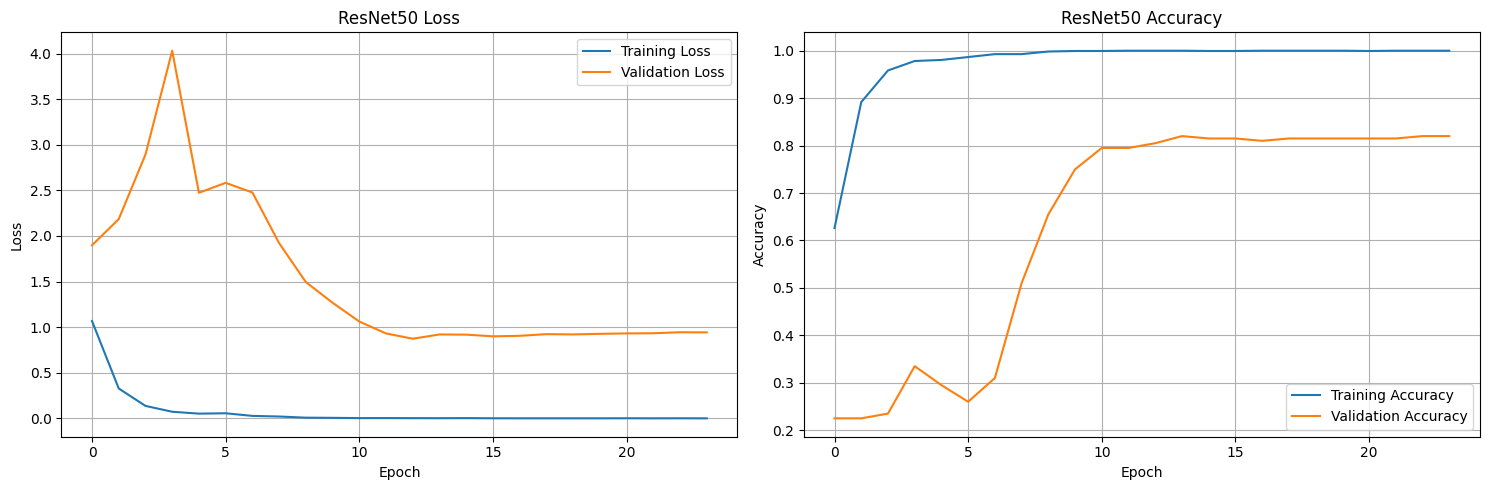

In [11]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

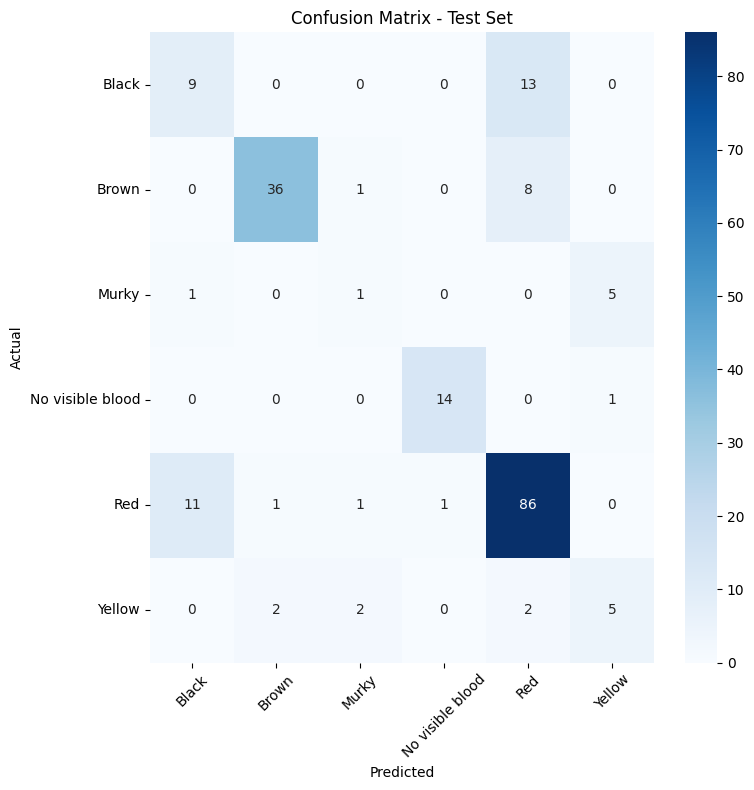

In [12]:
plt.figure(figsize=(8,8))
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()